In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# 45° Crossing with Virtual Cells

This page builds a **grid of 45° waveguide crossings** using schematic-driven design.
It demonstrates several advanced features working together:

- Direct polygon construction for the crossing cell
- Virtual parametric cells (`@pdk.vcell` / `VKCell`) for lightweight bend and straight
  components
- `DSchematic` (µm-coordinate schematic) with `output_type=DKCell`
- Hierarchical grid assembly driven entirely by schematic logic
- LVS verification and code generation from the resulting schematic

In [2]:
import warnings
from pprint import pformat

import numpy as np
from IPython.display import HTML

import kfactory as kf


def scrollable_text(text: str, max_height: str = "400px") -> HTML:
    """Render long text in a vertically scrollable, monospaced HTML block."""
    import html

    return HTML(
        f'<div style="max-height: {max_height}; overflow-y: auto; '
        f"font-family: monospace; white-space: pre; padding: 0.5em; "
        f'border: 1px solid #ccc;">{html.escape(text)}</div>'
    )

## PDK setup

We create a dedicated `KCLayout` with a wide waveguide cross-section.  The
`SymmetricalCrossSection` bundles the core width, enclosure (cladding), and a name
that the schematic can reference as a plain string.

In [3]:
class Layers(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


LAYER = Layers()
pdk = kf.KCLayout("CROSSING_PDK", infos=Layers)

xs_wg1 = pdk.get_icross_section(
    kf.SymmetricalCrossSection(
        width=1000,
        enclosure=kf.LayerEnclosure(
            [(LAYER.WGEX, 3000)], name="WG", main_layer=LAYER.WG
        ),
        name="WG1000",
    )
)

# The crossing45 schematic below is registered on kf.kcl, so ensure the same
# cross-section is available there as well.
kf.kcl.get_icross_section(xs_wg1)

## The `cross` cell

A single 45° crossing: four waveguide arms radiating from the center.

- Polygon points are generated per arm with a sinusoidal width profile
- All four rotations are merged with `Region.hulls()`
- `fix_spacing_tiled` resolves minimum-space DRC violations
- Enclosures are applied via `Minkowski` for cladding / fill-exclude layers
- Four ports (`o1`..`o4`) face the cardinal directions

In [4]:
@pdk.cell
def cross(cross_section: str) -> kf.KCell:
    c = pdk.kcell()
    xs = c.kcl.get_icross_section(cross_section)

    # Calculate points for one arm of the cross
    points = [
        kf.kdb.DPoint(
            x * 0.075, c.kcl.to_um(xs.width // 2) + float(np.sin(x / 125 * np.pi))
        )
        for x in range(101)
    ]
    mt = kf.kdb.DTrans.M0

    poly = kf.kdb.DPolygon(points + list(reversed([mt * p for p in points]))).to_itype(
        c.kcl.dbu
    )

    center_dist = c.kcl.to_dbu(points[-1].y)
    base_trans = kf.kdb.Trans(-poly.bbox().right - center_dist, 0)

    r = kf.kdb.Region(
        [
            poly.transformed(base_trans) * kf.kdb.Trans(rot, False, 0, 0)
            for rot in range(4)
        ]
    ).hulls()

    shapes = c.shapes(LAYER.WG)
    shapes.insert(r)

    # Fix minimum space violations for 300 dbu (0.3 um)
    fix = kf.utils.fix_spacing_tiled(c, 300, layer=LAYER.WG)
    shapes.clear()
    shapes.insert(fix)

    bb = c.bbox(c.kcl.layer(xs.main_layer))

    c.create_port(
        name="o1", trans=kf.kdb.Trans(0, False, bb.right, 0), cross_section=xs
    )
    c.create_port(name="o2", trans=kf.kdb.Trans(1, False, 0, bb.top), cross_section=xs)
    c.create_port(name="o3", trans=kf.kdb.Trans(2, False, bb.left, 0), cross_section=xs)
    c.create_port(
        name="o4", trans=kf.kdb.Trans(3, False, 0, bb.bottom), cross_section=xs
    )

    xs.enclosure.apply_minkowski_tiled(c, xs.main_layer)
    c.auto_rename_ports()

    return c

## Virtual cells

Unlike physical cells, **virtual cells** (`VKCell`) are defined parametrically and only
generate geometry when materialised.  They are lightweight and efficient for
repetitive routing primitives.

In [5]:
@pdk.vcell
def bend_euler(
    radius: float,
    cross_section: str,
    angle: float = 90,
    resolution: float = 150,
) -> kf.VKCell:
    """Virtual euler bend.

    Args:
        radius: Radius of the backbone. [um]
        cross_section: Name of the CrossSection.
        angle: Angle of the bend.
        resolution: Angle resolution for the backbone.
    """
    c = pdk.vkcell()
    xs = c.kcl.get_dcross_section(cross_section)
    dbu = c.kcl.dbu

    backbone = kf.factories.virtual.euler.euler_bend_points(
        angle, radius=radius, resolution=resolution
    )

    kf.factories.utils.extrude_backbone(
        c=c,
        backbone=backbone,
        width=xs.width,
        layer=xs.main_layer,
        enclosure=xs.enclosure,
        start_angle=0,
        end_angle=angle,
        dbu=dbu,
    )

    c.create_port(
        name="o1",
        cross_section=xs,
        dcplx_trans=kf.kdb.DCplxTrans(1, 180, False, backbone[0].to_v()),
    )
    c.create_port(
        name="o2",
        cross_section=xs,
        dcplx_trans=kf.kdb.DCplxTrans(1, angle, False, backbone[-1].to_v()),
    )

    return c


@pdk.vcell
def straight(length: float, cross_section: str) -> kf.VKCell:
    """Virtual straight waveguide.

    Args:
        length: Length in um.
        cross_section: Name of the CrossSection.
    """
    c = pdk.vkcell()
    xs = c.kcl.get_dcross_section(cross_section)

    kf.factories.utils.extrude_backbone(
        c,
        [kf.kdb.DPoint(0, 0), kf.kdb.DPoint(length, 0)],
        start_angle=0,
        end_angle=0,
        width=xs.width,
        layer=xs.main_layer,
        enclosure=xs.enclosure,
        dbu=c.kcl.dbu,
    )

    c.create_port(
        name="o1",
        dcplx_trans=kf.kdb.DCplxTrans(mag=1, rot=180, mirrx=False, x=0, y=0),
        cross_section=xs,
    )
    c.create_port(
        name="o2",
        dcplx_trans=kf.kdb.DCplxTrans(mag=1, rot=0, mirrx=False, x=length, y=0),
        cross_section=xs,
    )

    return c

## Crossing schematic

The `crossing45` schematic builds an n-by-n array of crossings:

- Tiles `cross` instances on a 45° grid
- Inserts straight spacers between crossings when the pitch exceeds the crossing size
- Adds 45° euler bends and I/O straights at the edges so that all ports face
  horizontally
- Uses `DSchematic` (µm coordinates) and produces a `DKCell`

2026-07-15 15:51:16.245 | INFO     | kfactory.enclosure:apply_minkowski_tiled:1028 - Starting minkowski on Unnamed_0


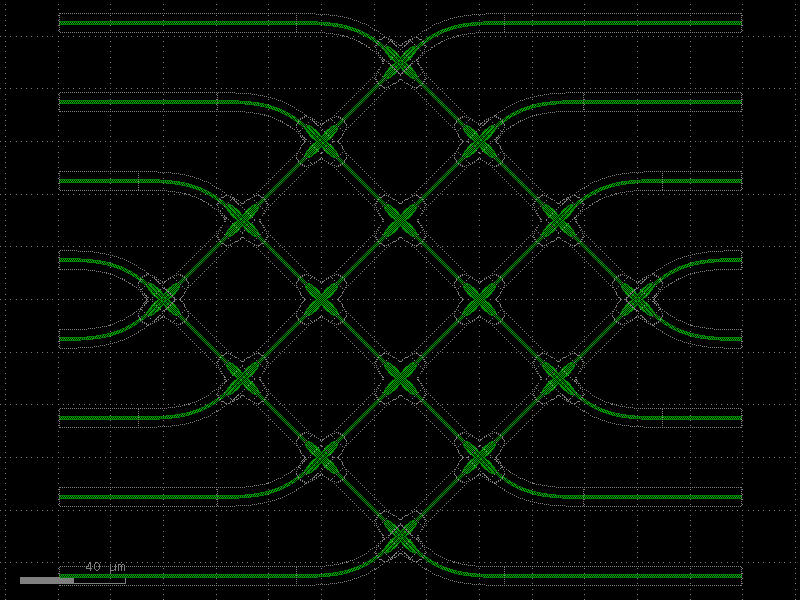

In [6]:
@kf.kcl.schematic_cell(output_type=kf.DKCell)
def crossing45(n: int, pitch: kf.typings.um, cross_section: str) -> kf.DSchematic:
    s = kf.DSchematic(kcl=kf.kcl)

    xs = s.kcl.get_dcross_section(cross_section)

    cross_cell = cross(cross_section=cross_section)

    cross_port_delta = (
        cross_cell.ports["o1"].dcplx_trans.disp
        - cross_cell.ports["o2"].dcplx_trans.disp
    ).length()
    width = cross_cell.dbbox(cross_cell.kcl.layer(xs.main_layer)).width()

    bend_cell = bend_euler(radius=30, cross_section=cross_section, angle=45)

    dy = abs(bend_cell.ports["o1"].y - bend_cell.ports["o2"].y)
    dl = float((pitch - cross_port_delta - dy * 2) / np.sqrt(2))

    d_w = float(pitch * np.sqrt(2) - width)
    if d_w < 0:
        raise ValueError(
            f"Pitch must be bigger than the crossing's size: crossing_width={width}, {pitch=}"
        )

    for i in range(n // 2):
        for j in range(n // 2):
            crossing = s.create_inst(
                name=f"crossing_{i}_{j}",
                component="cross",
                virtual=True,
                kcl=pdk,
                settings={"cross_section": xs.name},
            )

            if d_w > 0:
                match i, j:
                    case 0, 0:
                        crossing.place(orientation=45)
                    case 0, j:
                        wg_ij = s.create_inst(
                            name=f"spacer_{i}_{j}_1",
                            component="straight",
                            settings={"length": d_w, "cross_section": cross_section},
                            kcl=pdk,
                            virtual=True,
                        )
                        wg_ij.connect(
                            "o1", s.instances[f"crossing_{i}_{j - 1}"].ports["o4"]
                        )
                        crossing.connect("o2", wg_ij.ports["o2"])
                    case i, 0:
                        wg_ij = s.create_inst(
                            name=f"spacer_{i}_{j}_2",
                            component="straight",
                            settings={"length": d_w, "cross_section": cross_section},
                            kcl=pdk,
                            virtual=True,
                        )
                        wg_ij.connect(
                            "o1", s.instances[f"crossing_{i - 1}_{j}"].ports["o3"]
                        )
                        crossing.connect("o1", wg_ij.ports["o2"])
                    case i, j:
                        wg_ij1 = s.create_inst(
                            name=f"spacer_{i}_{j}_1",
                            component="straight",
                            settings={"length": d_w, "cross_section": cross_section},
                            kcl=pdk,
                            virtual=True,
                        )
                        wg_ij1.connect(
                            "o1", s.instances[f"crossing_{i}_{j - 1}"].ports["o4"]
                        )
                        wg_ij2 = s.create_inst(
                            name=f"spacer_{i}_{j}_2",
                            component="straight",
                            settings={"length": d_w, "cross_section": cross_section},
                            kcl=pdk,
                            virtual=True,
                        )
                        wg_ij2.connect(
                            "o1", s.instances[f"crossing_{i - 1}_{j}"].ports["o3"]
                        )
                        crossing.connect("o2", wg_ij1.ports["o2"])
                        crossing.connect("o1", wg_ij2.ports["o2"])
            else:
                match i, j:
                    case 0, 0:
                        crossing.place()
                    case 0, j:
                        crossing.connect(
                            "o2", s.instances[f"crossing_{i}_{j - 1}"].ports["o4"]
                        )
                    case i, 0:
                        crossing.connect(
                            "o1", s.instances[f"crossing_{i - 1}_{j}"].ports["o3"]
                        )
                    case i, j:
                        crossing.connect(
                            "o2", s.instances[f"crossing_{i}_{j - 1}"].ports["o4"]
                        )
                        crossing.connect(
                            "o1", s.instances[f"crossing_{i - 1}_{j}"].ports["o3"]
                        )

    for i in range(n // 2):
        spacer_start_top = s.create_inst(
            name=f"io_spacer_{i}",
            component="straight",
            settings={"length": dl, "cross_section": cross_section},
            kcl=pdk,
            virtual=True,
        )
        bend_start_top = s.create_inst(
            name=f"bend45_{i}",
            component="bend_euler",
            settings={"angle": 45, "cross_section": cross_section, "radius": 30},
            kcl=pdk,
            virtual=True,
        )
        bend_start_top.mirror = True
        spacer_start_top.connect("o2", s.instances[f"crossing_{i}_0"].ports["o2"])
        spacer_start_top.connect("o1", bend_start_top.ports["o2"])

        spacer_start_bot = s.create_inst(
            name=f"io_spacer_{n - 1 - i}",
            component="straight",
            settings={"length": dl, "cross_section": cross_section},
            kcl=pdk,
            virtual=True,
        )
        bend_start_bot = s.create_inst(
            name=f"bend45_{n - i - 1}",
            component="bend_euler",
            settings={"angle": 45, "cross_section": cross_section, "radius": 30},
            kcl=pdk,
            virtual=True,
        )
        spacer_start_bot.connect("o2", s.instances[f"crossing_0_{i}"].ports["o1"])
        spacer_start_bot.connect("o1", bend_start_bot.ports["o2"])

        spacer_end_top = s.create_inst(
            name=f"io_spacer_{n + i}",
            component="straight",
            settings={"length": dl, "cross_section": cross_section},
            kcl=pdk,
            virtual=True,
        )
        bend_end_top = s.create_inst(
            name=f"bend45_{n + i}",
            component="bend_euler",
            settings={"angle": 45, "cross_section": cross_section, "radius": 30},
            kcl=pdk,
            virtual=True,
        )
        bend_end_top.mirror = True
        spacer_end_top.connect(
            "o1", s.instances[f"crossing_{i}_{n // 2 - 1}"].ports["o4"]
        )
        spacer_end_top.connect("o2", bend_end_top.ports["o2"])

        spacer_end_bot = s.create_inst(
            name=f"io_spacer_{2 * n - i - 1}",
            component="straight",
            settings={"length": dl, "cross_section": cross_section},
            kcl=pdk,
            virtual=True,
        )
        bend_end_bot = s.create_inst(
            name=f"bend45_{2 * n - i - 1}",
            component="bend_euler",
            settings={"angle": 45, "cross_section": cross_section, "radius": 30},
            kcl=pdk,
            virtual=True,
        )
        spacer_end_bot.connect(
            "o1", s.instances[f"crossing_{n // 2 - 1}_{i}"].ports["o3"]
        )
        spacer_end_bot.connect("o2", bend_end_bot.ports["o2"])

        io_l_start = float(pitch * i)
        io_l_end = float((n // 2 - i - 1) * pitch)
        if io_l_start:
            io_straight_start_top = s.create_inst(
                name=f"io_straight_{i}",
                component="straight",
                settings={"length": io_l_start, "cross_section": cross_section},
                kcl=pdk,
                virtual=True,
            )
            io_straight_start_top.connect("o2", bend_start_top.ports["o1"])
            io_straight_start_bot = s.create_inst(
                name=f"io_straight_{n - 1 - i}",
                component="straight",
                settings={"length": io_l_start, "cross_section": cross_section},
                kcl=pdk,
                virtual=True,
            )
            io_straight_start_bot.connect("o2", bend_start_bot.ports["o1"])

            s.add_port(name=f"in_{n // 2 + i}", port=io_straight_start_top.ports["o1"])
            s.add_port(
                name=f"in_{n // 2 - 1 - i}", port=io_straight_start_bot.ports["o1"]
            )
        else:
            s.add_port(name=f"in_{n // 2 + i}", port=bend_start_top.ports["o1"])
            s.add_port(name=f"in_{n // 2 - 1 - i}", port=bend_start_bot.ports["o1"])
        if io_l_end:
            io_straight_end_top = s.create_inst(
                name=f"io_straight_{n + i}",
                component="straight",
                settings={"length": io_l_end, "cross_section": cross_section},
                kcl=pdk,
                virtual=True,
            )
            io_straight_end_top.connect("o2", bend_end_top.ports["o1"])
            io_straight_end_bot = s.create_inst(
                name=f"io_straight_{2 * n - 1 - i}",
                component="straight",
                settings={"length": io_l_end, "cross_section": cross_section},
                kcl=pdk,
                virtual=True,
            )
            io_straight_end_bot.connect("o2", bend_end_bot.ports["o1"])
            s.add_port(name=f"out_{n // 2 + i}", port=io_straight_end_top.ports["o1"])
            s.add_port(
                name=f"out_{n // 2 - 1 - i}", port=io_straight_end_bot.ports["o1"]
            )
        else:
            s.add_port(name=f"out_{n // 2 + i}", port=bend_end_top.ports["o1"])
            s.add_port(name=f"out_{n // 2 - 1 - i}", port=bend_end_bot.ports["o1"])

    return s


c = crossing45(8, pitch=30, cross_section="WG1000")
c

## Inspecting the schematic model

The schematic model contains every instance, placement, and connection as a
serialisable Pydantic structure.

In [7]:
with warnings.catch_warnings():
    # capture pydantic serialization warnings due to generic type mismatch
    warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")
    scrollable_text(pformat(c.schematic.model_dump(exclude_defaults=True)))

## LVS: schematic vs extracted netlist

With both a schematic netlist (derived from declared connections) and an extracted
netlist (derived from physical geometry), we can verify they match.

In [8]:
schematic_netlist = c.schematic.netlist().normalize()
extracted_netlist = c.netlist()[c.name].normalize()

assert schematic_netlist == extracted_netlist, "LVS failed!"
print("LVS passed: schematic and extracted netlists match.")

LVS passed: schematic and extracted netlists match.


## Code generation

`code_str()` exports the schematic as a standalone Python function.  The generated
code re-creates the same layout without the schematic machinery and can be shared
with collaborators or archived for reproducibility.

In [9]:
from IPython.display import Code

Code(c.schematic.code_str())

2026-07-15 15:51:16.591 | WARNING  | kfactory.schematic:code_str:2246 - Ruff not found or installed. Returning unformatted string.


import kfactory as kf


kcl = kf.kcls["DEFAULT"]

@kcl.schematic_cell(output_type=kf.DKCell)
def crossing45_N8_P30_CSWG1000() -> kf.DSchematic:
  schematic = kf.DSchematic(kcl=kcl)

  # Create the schematic instances
  bend45_0 = schematic.create_inst(
    name='bend45_0',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_1 = schematic.create_inst(
    name='bend45_1',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_10 = schematic.create_inst(
    name='bend45_10',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_11 = schematic.create_inst(
    name='bend45_11',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_12 = schematic.create_inst(
    name='bend45_12',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_13 = schematic.create_inst(
    name='bend45_13',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_14 = schematic.create_inst(
    name='bend45_14',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_15 = schematic.create_inst(
    name='bend45_15',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_2 = schematic.create_inst(
    name='bend45_2',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_3 = schematic.create_inst(
    name='bend45_3',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_4 = schematic.create_inst(
    name='bend45_4',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_5 = schematic.create_inst(
    name='bend45_5',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_6 = schematic.create_inst(
    name='bend45_6',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_7 = schematic.create_inst(
    name='bend45_7',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_8 = schematic.create_inst(
    name='bend45_8',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  bend45_9 = schematic.create_inst(
    name='bend45_9',
    component='bend_euler',
    settings={'angle': 45, 'cross_section': 'WG1000', 'radius': 30},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  crossing_0_0 = schematic.create_inst(
    name='crossing_0_0',
    component='cross',
    settings={'cross_section': 'WG1000'},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  crossing_0_1 = schematic.create_inst(
    name='crossing_0_1',
    component='cross',
    settings={'cross_section': 'WG1000'},
    kcl=kf.kcls["CROSSING_PDK"],
    virtual=True,
  )
  crossing_0_2 = schematic.create_inst(
    name='crossin

## Summary

This example combined several advanced kfactory features:

| Feature | Where used |
|---------|-----------|
| Direct polygon construction | `cross` cell — sinusoidal arm profile with `Region.hulls()` |
| DRC fixing | `fix_spacing_tiled` inside the crossing cell |
| Minkowski enclosures | `apply_minkowski_tiled` for cladding layers |
| Virtual cells (`VKCell`) | `bend_euler` and `straight` — lightweight parametric geometry |
| `DSchematic` (µm coordinates) | `crossing45` — floating-point placement |
| `schematic_cell(output_type=DKCell)` | Produces a µm-based cell from the schematic |
| Grid assembly via schematic logic | Nested loops tile crossings, spacers, bends, and I/O |
| LVS verification | `schematic.netlist() == cell.netlist()` |
| Code generation | `schematic.code_str()` for portable export |

## See Also

| Topic | Where |
|-------|-------|
| Schematic basics (placement, connect, LVS) | [Schematics: Overview](overview.py) |
| Netlist data model & serialization | [Schematics: Netlist](netlist.py) |
| Virtual cells in detail | [Components: Virtual Cells](../components/cells/virtual.py) |
| Cross-sections & enclosures | [Cross-Sections](../components/cross_sections.py) |